# **Data Science Mini Project:** `Predicting health outcomes in Bristol using access to greenspace indicators.`

# **Section 1: Introduction and Background**
This project aims to assess whether ordnance survey data containing average access to local greenspace, number of postcodes in a built up area and IMD rank can be used to build an accurate supervised learning model that can accurately predict if an LSOA in Bristol has a general healthy or unhealthy population. Previous studies have focused on using supervised machine learning classification models such as K nearest neighbours (Suyal and Goyal,2022) and decision trees to predict specific health conditions such as Covid-19 (Muhammad et al.,2020), however there are few studies that quantify overall general health across local communities.

This study sets out a clear workflow that cleans and joins data sets to answer set research questions and will create a set of health class labels based on Office for National Statistics data to train two models that will be able to classify LSOAs across Bristol into ‘healthy’ and ‘unhealthy’ areas, this information can then be used by local planning organisations and governments to quantify the importance of access to greenspace, population density and deprivation level on public health when planning new housing developments (Shaw, 2004, Fenning and Ting, 2025).

In 2021, the office for national statistics reported that on average around 80% of people in the UK reported their health as either very good (47.5%) or good (34.1%)(Office for National Statistics, 2023). Based on this information, the threshold for ‘healthy’ LSOA’s in this report was set at 80% (healthy population in a LSOA), however this is an indication of the top band of health and could be lowered in future studies to help inform policy makers on which LSOAs are the most vulnerable. This information would help local governments distribute healthcare facilities and hopefully increase overall health in LSOAs with high deprivation ranking (Oates and Firth, 2020).

Greenspace has been found to have direct links to public health increasing physical as well as mental wellbeing (Rishardson et al.,2013, Wolch et al.,2014). A study in 2021 (Matheney et al.2021), established that in Bristol, whilst having over 400 public parks and wildlife hubs, not all residents had easy access to greenspace due to large inequalities between communities primarily due to problems such as income and health inequalities. These factors make Bristol a good place to assess when looking at variation in health across LSOAs, this study will look at how IMD rank and greenspace relate to health across Bristol. It is acknowledged that IMD rank is partially decided by health factors per LSOA (Watson et al.,2019), this could introduce slight bias when creating supervised learning models however, it is important to include due to its inclusion of other measures of deprivation such as employment level, crime and education level. The use of number of postcodes per built up area gives an indication of population density assessing the spatial variation in residents across Bristol providing context to health variations.


# **Section 2: Research Questions**

***Question 1:*** Are the data variables suitable for predicting health class?

***Question 2:*** Can a supervised leaning model accurately predict whether an LSOA is classed as healthy or unhealthy based on average distance to green space (m), IMD rank per LSOA and number of postcodes in a built up area?

***Question 3:*** Which type of Supervised learning model is most effective a Decision tree or Knn (k nearest neighbours )?


# **Section 3: Overveiw**

***Brief project overveiw stating what is done in each sesction:***

*   **Data** - Introducing the data sets used in the study explaining where they where accessed how the relate to the project and how they can be combined with each other to answer the research questions.

*   **Description, Statistics and wrangling** - Investigating the datasets to gain a better understanding of what they include and how they could be used to help answer the research questions. Initial statistics such as mean values and ranges help to gain understanding of trends in the data and relationships between variables. The wrangling process includes formatting, cleaning, creation of dummies ect allowing for data joins so that later analysis can occur smoothly.

*  **Analysis** - Chloropleths are used for an intial visualisation of spatial pattern and correlations between variables helping to answer research question 1. Statistical comparisions are then made using a heatmap to identify strong/weak relationships to provided statistical evidence for spatial observations. To help answer questions 2 and 3, two models are created using the dummy varaibles created during data wrangling to form healthclass labels for model prediction. Model reports are produced so their accuracy can be assessed in the results section.

*  **Results** - The results assess the outcomes produced from data analysis.

*  **Discussion** - Discussing the outputs of the results and explaining them using literature. The precision and accuracy of the models are assessed identifing which works best with the provided data. Potencial improvements are identified that could be implemented in future studies.

*  **Conclusion** - Summarising the project and stating key takeaways.






# **Section 4: Data**

**Nomis 2021 Census Data (2021)** - General Health (TS037). Available at: https://www.nomisweb.co.uk/datasets/c2021ts037 (Accessed:20/01/26)

General health data (csv) was obtained from the Office for National Statistics nomis data finder. This data was collected at a LSOA level during the 2021 census and represents persons per health catagory as well as all usual residents per LSOA boundary. This data is crucial for establishing a threshold for catagorising healthy and unhealthy LSOAs that can be used as labels in the creation of supervised learning models.

**Ordnance Survey Access to Public Greenspace data (2020)** - Available at: https://www.ons.gov.uk/economy/environmentalaccounts/datasets/accesstogardensandpublicgreenspaceingreatbritain (Accessed:20/01/26)

OS Greenspace data (csv) was obtained from the Office of National Statistics, it displays multiple variables assosiated with access to greenspace across the whole UK. This data is useful as it will aid the creation of train data for supervised learning classification models. This data can be joined spatially at a LSOA level to Bristol boundary shapefiles and can also be joined to csv health data from Bristol on common join columns.


**Bristol LSOA shapefile (2021)** - Open Data Bristol. Available at: https://opendata.bristol.gov.uk/datasets/lower-layer-super-output-areas-2021-precise/about (Accessed:20/01/26)

Bristol LSOA boundries (shp) where obtained from the Bristol open data portal, this data shows LSOAs as they where in 2021. This data can be joined to both health and greenspace csv data files to create a spatial visualisation of key variables by matching them to geometry that can then be plotted.  

In [ ]:
# Download packages
# Needed for chloropleth spatial data visualisation
!pip install git+https://github.com/pmdscully/geo_northarrow.git
!pip install matplotlib-scalebar

  Cloning https://github.com/pmdscully/geo_northarrow.git to /tmp/pip-req-build-972pch6_
  Running command git clone --filter=blob:none --quiet https://github.com/pmdscully/geo_northarrow.git /tmp/pip-req-build-972pch6_
  Resolved https://github.com/pmdscully/geo_northarrow.git to commit c530ad3f9558d05355543e9fe7671f26cd0ffa02
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for geo_northarrow: filename=geo_northarrow-0.2.0a0-py3-none-any.whl size=14938 sha256=f697a8f8fd1ae886db90df706e1667781f9f65595756d2fd7919b84523661e35
  Stored in directory: /tmp/pip-ephem-wheel-cache-4fbyqugf/wheels/d7/28/6c/cb006605c19bc4f58db715626f7113a6858d8c002e8c52fa80
Successfully built geo_northarrow


In [ ]:
# Import packages to load in data
import pandas as pd
import numpy as np

# For Spatial visualisation
import geopandas as gpd
from geo_northarrow import add_north_arrow
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.image as img

# For data visulaisation
import seaborn as sns
import matplotlib.pyplot as plt

# Ttests
from scipy.stats import ttest_ind

# Creating model labels
from sklearn.preprocessing import LabelEncoder

# Train test split package used to train supervised learning models
from sklearn.model_selection import train_test_split

# Descision Tree
from sklearn.tree import DecisionTreeClassifier

# Knearest neighbours
from sklearn.neighbors import KNeighborsClassifier

# Confusion matrix packages for visualising model outcomes
from sklearn import metrics

In [ ]:
# Load in csv containing Greenspace data using pandas
greenspace = pd.read_csv('Accsess_to_greenspace.csv')

# Load in the csv data containg health data for Bristol using pandas
bristol_health = pd.read_csv('bristol_health_lsoa.csv')

# Load in LSOA .shp files for Bristol using geopandas
LSOA_bristol = gpd.read_file('/content/Lower_Layer_Super_Output_Areas_2021_(Precise).shp')

# **Section 5: Data Description, Statistics and Wrangling**

This section investigates the data and uses initial statistical analysis and visualisation to gain a better understanding of the data variables. Data wrangling prepares the data for later analysis and includeds the creation of dummy variables and joining datasets together.

***Greenspace data - Data description***

In [ ]:
# View the greenspace data, veiw number of columns/names (19) and number of rows (32649)
greenspace

,Country_code,Country_name,Region_code,Region_name,LAD_code,LAD_name,MSOA_code,MSOA_name,LSOA21CD,LSOA_name,IMD_rank_country_specific,IMD_decile_country_specific,Average_distance_nearest_Park_Public_Garden_m,Average_size_nearest_Park_Public_Garden_m2,Average_number_Parks_Public_Gardens_within_1000_m_radius,Average_combined_size_Parks_Public_Gardens_within_1000m_radius_m2,Number_postcodes_within_built_up_area,Number_built_up_area_postcodes_within_300m_Park_Public_Garden,Number_built_up_area_postcodes_within_900m_Park_Public_Garden
0,E92000001,England,E12000007,London,E09000001,City of London,E02000001,City of London 001,E01000001,City of London 001A,29199,9,183.600000,2862.510000,10.410000,2.410456e+04,54,51,54
1,E92000001,England,E12000007,London,E09000001,City of London,E02000001,City of London 001,E01000002,City of London 001B,30379,10,332.710000,3110.620000,9.990000,1.846643e+04,84,30,84
2,E92000001,England,E12000007,London,E09000001,City of London,E02000001,City of London 001,E01000003,City of London 001C,14915,5,153.090000,3537.770000,9.530000,3.094224e+04,34,34,34
3,E92000001,England,E12000007,London,E09000001,City of London,E02000001,City of London 001,E01000005,City of London 001E,8678,3,164.260000,603.000000,12.240000,4.713426e+04,100,92,100
4,E92000001,England,E12000007,London,E09000002,Barking and Dagenham,E02000017,Barking and Dagenham 016,E01000006,Barking and Dagenham 016A,14486,5,246.650000,39927.220000,4.570000,4.742585e+05,14,11,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32644,E92000001,England,E12000002,North West,E08000012,Liverpool,E02001368,Liverpool 022,E01033764,Liverpool 022E,116,1,192.723667,16608.303980,10.320611,4.132906e+05,131,112,131
32645,E92000001,England,E12000002,North West,E08000012,Liverpool,E02006933,Liverpool 061,E01033765,Liverpool 061D,945,1,264.243372,8871.941221,5.437500,3.276967e+04,48,30,48
32646,E92000001,England,E12000002,North West,E08000012,Liverpool,E02001388,Liverpool 042,E01033766,Liverpool 042G,12842,4,171.181848,46825.414100,3.058824,1.043149e+06,17,17,17
32647,E92000001,England,E12000002,North West,E08000012,Liverpool,E02001396,Liverpool 050,E01033767,Liverpool 050J,422,1,174.452837,8047.609950,3.730769,4.335301e+05,26,25,26


In [ ]:
# Veiw the data types within the greenspace dataset
greenspace.dtypes

,0
Country_code,object
Country_name,object
Region_code,object
Region_name,object
LAD_code,object
LAD_name,object
MSOA_code,object
MSOA_name,object
LSOA21CD,object
LSOA_name,object


In [ ]:
# Check if the dataset contains NA values
greenspace.isna().sum()

,0
Country_code,0
Country_name,0
Region_code,0
Region_name,0
LAD_code,0
LAD_name,0
MSOA_code,0
MSOA_name,0
LSOA21CD,0
LSOA_name,0


The Greenspace dataset contains 32649 rows and 19 columns. There are 10 x 'object' data types containing text or string values, these columns display location data such as country names (in this case England) city names (such as Bristol) and LSOA codes (eg. E01000001) that can be used to join data sets together and visualise infomation spatially.

There are 5 x 'int64' columns containing whole number values such as IMD Rank number of postcodes within a built up areas, these values are useful for understanding the population density/distribution around Bristol . IMD Rank is usesful for visualising deprivation levels across all 33,755 LSOAs of the UK. Each LSOA is ranked from most deprived (1) to least deprived (33,755) these values can be a good indicator of factors such as education level, employment status and health.

The dataset also includes 4 x 'float64' data types consisting of values with a decimal point such as a percentage or distance measurements such as average distance (meters) to nearest public park/garden. Accsess to greenspace has been directly correlated to health and therefore is an inportant variable to include in this study.

The dataset contained no missing values, however, if present rows containg NA values would have be remove. This would introduce a slight bias in the data and could lead to the loss of some useful infomation but it would improve overall data accuracy and future model performace.

***Greenspace data - Key variable exploration***

In [ ]:
# Filter greenspace data to just show Average distance to the nearest Park/Public Garden data from 'LAD_name' == Bristol
avg_distance_brist = greenspace[greenspace['LAD_name'] == 'Bristol, City of']['Average_distance_nearest_Park_Public_Garden_m']

# Assign bristol_mean to the average distance value for Bristol
bristol_mean = avg_distance_brist.mean()

# Round to 2 decimal places
print(round(bristol_mean, 2))

337.24


In [ ]:
# Provide UK context for Bristol mean
# Display the 3 largest values for average distance to nearest public park
greenspace.nlargest(3, 'Average_distance_nearest_Park_Public_Garden_m')

,Country_code,Country_name,Region_code,Region_name,LAD_code,LAD_name,MSOA_code,MSOA_name,LSOA21CD,LSOA_name,IMD_rank_country_specific,IMD_decile_country_specific,Average_distance_nearest_Park_Public_Garden_m,Average_size_nearest_Park_Public_Garden_m2,Average_number_Parks_Public_Gardens_within_1000_m_radius,Average_combined_size_Parks_Public_Gardens_within_1000m_radius_m2,Number_postcodes_within_built_up_area,Number_built_up_area_postcodes_within_300m_Park_Public_Garden,Number_built_up_area_postcodes_within_900m_Park_Public_Garden
19660,E92000001,England,E12000009,South West,E07000046,Torridge,E02004224,Torridge 005,E01020292,Torridge 005B,11343,4,17313.64223,208360.8192,1.0,208360.0,39,0,0
26899,E92000001,England,E12000003,Yorkshire and The Humber,E07000166,Richmondshire,E02005786,Richmondshire 005,E01027753,Richmondshire 005B,25519,8,13619.52898,12261.9021,1.0,12261.0,51,0,0
27978,E92000001,England,E12000005,West Midlands,E06000051,Shropshire,E02006020,Shropshire 009,E01028871,Shropshire 009C,11546,4,13291.75214,382820.9509,1.0,382820.0,14,0,0


In [ ]:
# Provide UK context for Bristol mean
# Display the 3 smallest values for average distance to nearest public park
greenspace.nsmallest(3, 'Average_distance_nearest_Park_Public_Garden_m')

,Country_code,Country_name,Region_code,Region_name,LAD_code,LAD_name,MSOA_code,MSOA_name,LSOA21CD,LSOA_name,IMD_rank_country_specific,IMD_decile_country_specific,Average_distance_nearest_Park_Public_Garden_m,Average_size_nearest_Park_Public_Garden_m2,Average_number_Parks_Public_Gardens_within_1000_m_radius,Average_combined_size_Parks_Public_Gardens_within_1000m_radius_m2,Number_postcodes_within_built_up_area,Number_built_up_area_postcodes_within_300m_Park_Public_Garden,Number_built_up_area_postcodes_within_900m_Park_Public_Garden
31764,E92000001,England,E12000007,London,E09000030,Tower Hamlets,E02000873,Tower Hamlets 010,E01032785,Tower Hamlets 010E,13712,5,57.931730,49891.22431,14.153846,1.198437e+06,26,26,26
32203,E92000001,England,E12000003,Yorkshire and The Humber,E08000019,Sheffield,E02006844,Sheffield 074,E01033267,Sheffield 074E,12156,4,58.162816,10531.46790,7.315789,2.004208e+05,19,19,19
4188,E92000001,England,E12000007,London,E09000030,Tower Hamlets,E02000889,Tower Hamlets 026,E01004295,Tower Hamlets 026C,7506,3,64.601121,12595.26010,17.218750,9.758134e+04,32,32,32


In [ ]:
# Filter greenspace data to just show IMD Rank data from 'LAD_name' == Bristol
IMD_rank_brist = greenspace[greenspace['LAD_name'] == 'Bristol, City of']['IMD_rank_country_specific']

# Assign bristol_mean_IMD to the average IMD Rank value for Bristol
bristol_mean_IMD = IMD_rank_brist.mean()

# Round to 2 decimal places
print(round(bristol_mean_IMD, 2))

13542.15


In [ ]:
# Filter greenspace data to just show Number of postcodes within a built up area data from 'LAD_name' == Bristol
avg_number_brist = greenspace[greenspace['LAD_name'] == 'Bristol, City of']['Number_postcodes_within_built_up_area']

# Assign bristol_mean_postcodes to the average number postcodes value for Bristol
bristol_mean_postcodes = avg_number_brist.mean()

# Round to 2 decimal places
print(round(bristol_mean_postcodes, 2))

42.34


Through exploritory data analysis the 3 main Greenspace variables used in this study (IMD Rank, Number of postcodes within a built up areas and Average distance to nearest park/public garden) can be explored. Greenspace data was filtered to only included variables from Bristol. Mean averages were calculated, Bristol's average distance to public greenspace was 337.24m, the lowest value recorded across the UK was 57m with the highest distance at 17,313m. Mean IMD rank was 13542.15 suggesting that there are some LSOAs in the City of Bristol with extremely low rankings. The mean number of postcodes in a built up area was 42.34 suggesting that Bristol is not densely populated.


***Creating a Greenspace Subset***

In [ ]:
# Create a data subset only containing data from Bristol
# From within the greenspace column 'LAD_name' the rows containing values 'Bristol' are moved into a new subset using the .isin function (Pandas, 2026).
greensub = greenspace[greenspace['LAD_name'].isin(['Bristol, City of'])]

In [ ]:
# Check the subset contains data from Bristol by checking the unique values of the 'LAD_name' column
greensub['LAD_name'].unique()

array(['Bristol, City of'], dtype=object)

In [ ]:
# Find and replace 'Bristol, City of' with 'Bristol' for consistancy purposes between datasets
# Using the .loc function replace the values in the column 'LAD_name' equal to 'Bristol, City of' with 'Bristol', this doesnt remove any data just replaces one value with the desired one.
greensub.loc[greensub['LAD_name'] == 'Bristol, City of', 'LAD_name'] = 'Bristol'

In [ ]:
# Remove columns that are not need for the analysis
greensub = greensub[['LAD_name', 'LSOA21CD','IMD_rank_country_specific',
                     'Average_distance_nearest_Park_Public_Garden_m','Number_postcodes_within_built_up_area']]

In [ ]:
# Veiw the new subset to see if has worked correctly
# 263 rows and 5 columns
greensub

,LAD_name,LSOA21CD,IMD_rank_country_specific,Average_distance_nearest_Park_Public_Garden_m,Number_postcodes_within_built_up_area
14035,Bristol,E01014485,12992,152.279693,55
14036,Bristol,E01014486,3573,96.271032,71
14037,Bristol,E01014487,17138,255.706772,30
14038,Bristol,E01014488,11617,294.922881,45
14039,Bristol,E01014489,5787,468.261741,48
...,...,...,...,...,...
32272,Bristol,E01033364,13349,484.895933,51
32273,Bristol,E01033366,2559,241.901043,31
32274,Bristol,E01033367,1223,492.265490,44
32275,Bristol,E01033369,1657,239.473652,40


Creating a greenspace subset containing only Bristol data will make data joining smoother and less cluttered. Unique LAD_name values were checked to ensure the subset had been created correctly. In the original greenspace dataset Bristol was labeled as 'Bristol, City of', for consistancy between databases this was changed to 'Bristol'.

Extra columns containing variables not nessessary for this project were then removed so that it is clear what variables are being used.

***Health Data - Data description***

In [ ]:
# View the bristol health dataset
# 267 rows and 9 columns
bristol_health

,LAD_name,2021_super_output_area_lower_layer,LSOA21CD,Very_good_health,Good_health,Fair_health,Bad_health,Very_bad_health,All_usual
0,Bristol,Bristol 045B,E01014580,628,462,276,158,49,"1,573"
1,Bristol,Bristol 049E,E01014706,492,459,248,128,37,"1,364"
2,Bristol,Bristol 002D,E01014691,754,680,370,147,55,"2,006"
3,Bristol,Bristol 051B,E01014595,554,442,255,104,37,"1,392"
4,Bristol,Bristol 051D,E01014597,553,445,259,103,32,"1,392"
...,...,...,...,...,...,...,...,...,...
262,Bristol,Bristol 020D,E01014669,973,498,95,21,8,"1,595"
263,Bristol,Bristol 060A,E01014538,"1,124",543,112,18,8,"1,805"
264,Bristol,Bristol 017D,E01014667,"1,141",442,97,24,5,"1,709"
265,Bristol,Bristol 016D,E01014511,923,405,83,19,3,"1,433"


In [ ]:
# Check if the dataset contains NA values
bristol_health.isna().sum()

,0
LAD_name,0
2021_super_output_area_lower_layer,0
LSOA21CD,0
Very_good_health,0
Good_health,0
Fair_health,0
Bad_health,0
Very_bad_health,0
All_usual,0


In [ ]:
# Check the data types
# 'Very_good_health', 'Good_health' and 'All_usual' columns are coming up an 'object' data types, this suggests that the columns contain ',' therefore not dispaying as a numeric data type
# This can be corrected during the data wrangling process
bristol_health.dtypes

,0
LAD_name,object
2021_super_output_area_lower_layer,object
LSOA21CD,object
Very_good_health,object
Good_health,object
Fair_health,int64
Bad_health,int64
Very_bad_health,int64
All_usual,object


The Bristol health data contains 267 rows and 9 columns with no missing data (no NA values).

The health data contains 6 x 'object' columns and 3 x 'int64' columns. Three object columns contain numeric values (Very_good_health, Good_health and All_Usual), these columns should display 'int64' dtypes. Reasons for this might include the addition of non-numeric characters such as commas converting the column values to text, this can be checked and corrected before futher analysis occurs as statistical analysis and dataset joins will not work correctly if left as is.

***Correcting dtypes in Bristol Health dataset***

In [ ]:
# Variables with dtype 'object' that are expected to be 'int64' may contain extra characters such as commas
# Unique values of an object column can be checked, this will return an array of all values within the specific column
bristol_health['Very_good_health'].unique()

array(['628', '492', '754', '554', '553', '682', '731', '696', '640',
       '889', '677', '700', '678', '672', '646', '720', '622', '661',
       '673', '603', '643', '630', '684', '560', '701', '730', '658',
       '654', '694', '717', '806', '821', '710', '914', '933', '868',
       '800', '751', '624', '828', '952', '660', '988', '691', '555',
       '698', '1,034', '773', '832', '1,090', '829', '651', '812', '904',
       '772', '794', '874', '746', '1,403', '702', '652', '825', '853',
       '1,119', '716', '807', '845', '799', '1,076', '837', '769', '693',
       '1,094', '707', '820', '1,037', '927', '1,008', '668', '877',
       '957', '871', '1,057', '758', '657', '1,278', '860', '625', '919',
       '809', '742', '830', '1,247', '1,221', '1,273', '641', '803',
       '924', '760', '675', '852', '785', '834', '947', '973', '787',
       '790', '699', '715', '844', '653', '1,365', '745', '1,107',
       '1,342', '1,148', '1,138', '1,481', '867', '953', '833', '613',
       '69

In [ ]:
# Values over 1000 contain a comma eg. 1,200, this can be corrected using str.replace

# Use the .str.replace function to remove commas, regex=False ensures the "," is treated as a literal character and not as a pattern
# str.strip removes blank space between charaters
bristol_health['Very_good_health'] = (bristol_health['Very_good_health'].str.replace(',', '', regex=False).str.strip())
bristol_health['Good_health'] = (bristol_health['Good_health'].str.replace(',', '', regex=False).str.strip())
bristol_health['All_usual'] = (bristol_health['All_usual'].str.replace(',', '', regex=False).str.strip())

# Convert the 'Very_good_health', 'Good_health' and 'All_usual' columns from a 'object' to 'Int64' using .astype()
bristol_health['Very_good_health'] = bristol_health['Very_good_health'].astype('Int64')
bristol_health['Good_health'] = bristol_health['Good_health'].astype('Int64')
bristol_health['All_usual'] = bristol_health['All_usual'].astype('Int64')

In [ ]:
# Check to see if the conversion has worked
bristol_health.dtypes

,0
LAD_name,object
2021_super_output_area_lower_layer,object
LSOA21CD,object
Very_good_health,Int64
Good_health,Int64
Fair_health,int64
Bad_health,int64
Very_bad_health,int64
All_usual,Int64


Using the .unique() function an array of unique values can be returned for a  specific column. The variable Very_good_health contained values containing a comma, this was removed and replaced with a blank space which was then removed using the str.strip() function. All column where then converted to int64 data types so they could be used in numeric data analysis.

The Bristol health data now contains 3 object variables which consist of geographical location data such as LSOA21CD, this is a common column with the Greenspace data so datasets can be merged on this column, data can also be linked to the same spatial polygon data through this column when creating chloropleth maps.

There are 6 x 'int64', these consist of health variables which display the total number of persons in each LSOA and how many of them fit into each health care catagory eg. Very good health.

***Bristol Health - Variable visualisation***

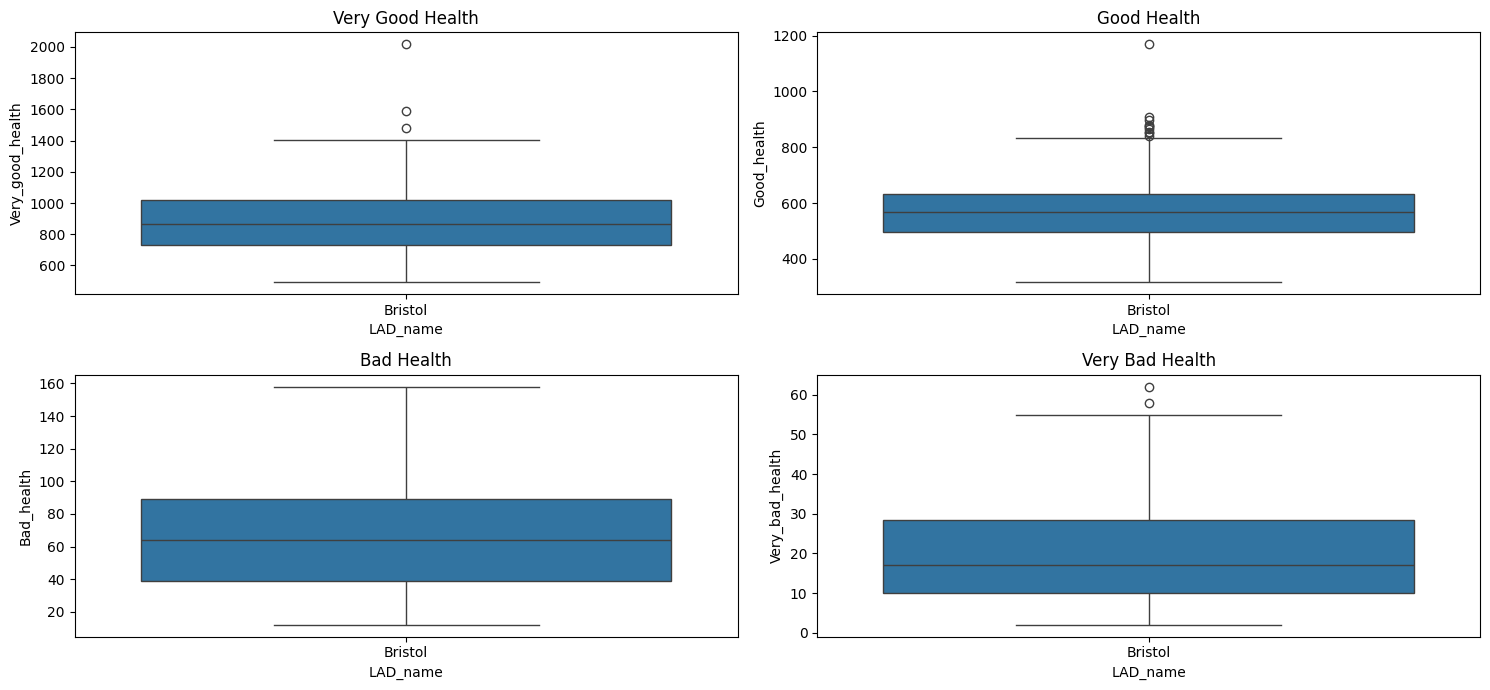

In [ ]:
# Visualise the distribution of Bristol's health variables
# Create a 2x2 multi plot figure and set the figure size
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize=(15, 7))

# Plot 1
# Create a boxplot displaying very good health in bristol
# Set the Yaxis to the chosen variable, and set the axis so that the plot is displayed on the top left, set the title to the specified axis
sns.boxplot(data =bristol_health, x = 'LAD_name', y = 'Very_good_health', ax = axes[0,0]).set_title('Very Good Health')

# Plot 2
# Create a boxplot displaying good health in bristol
# Set the Yaxis to the chosen variable, and set the axis so that the plot is displayed on the top right, set the title to the specified axis
sns.boxplot(data =bristol_health, x = 'LAD_name', y = 'Good_health',ax = axes[0,1]).set_title('Good Health')

# Plot 3
# Create a boxplot displaying bad health in bristol
# Set the Yaxis to the chosen variable, and set the axis so that the plot is displayed on the bottom left, set the title to the specified axis
sns.boxplot(data =bristol_health, x = 'LAD_name', y = 'Bad_health', ax = axes[1,0]).set_title('Bad Health')

# Plot 4
# Create a boxplot displaying very bad health in bristol
# Set the Yaxis to the chosen variable, and set the axis so that the plot is displayed on the top left, set the title to the specified axis
sns.boxplot(data =bristol_health, x = 'LAD_name', y = 'Very_bad_health', ax = axes[1,1]).set_title('Very Bad Health')

# Space out subplots
plt.tight_layout()

plt.show()

Box plots provide a good visual description of dataset variables making outliers visable and providing context before analysis. The data shows that the variable with the highest mean is very good health showing that a higher proportion of people per LSOA in Bristol reported very good health over all other health variables. The lowest mean was from very bad health showing that around 17 persons on average per LSOA in Bristol reported there health very bad. All but Bad heath displayed outliers, showing that some LSOAs in Bristol either have extremly good or extremly bad health.

***Visualisation of correlation between variables***

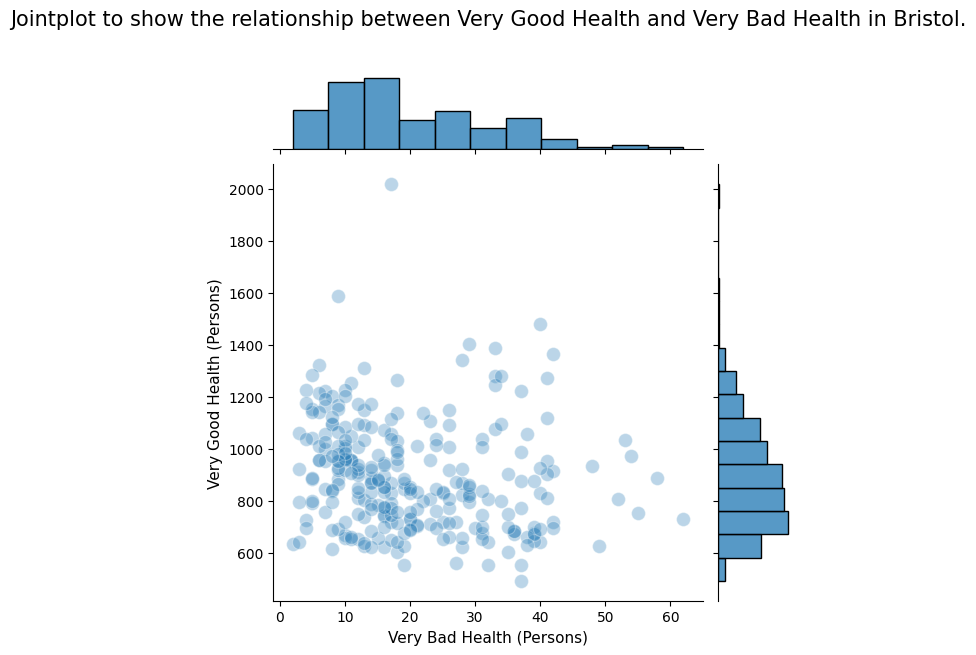

In [ ]:
# Intial data visualisation of Very good health and Very bad health data
# A jointplot showing the interaction between very good health and very bad health in Bristol.
sns.jointplot(y=bristol_health['Very_good_health'], x=bristol_health['Very_bad_health'], s = 100, alpha = 0.3)

# Set the title of the plot and plot it, position the title above the plot and inlarge the fontsize
plt.title('Jointplot to show the relationship between Very Good Health and Very Bad Health in Bristol.', y= 1.3, fontsize = 15)

# PLot the x and y lables adding in units, make the font size bigger
plt.xlabel("Very Bad Health (Persons)", fontsize= 11)
plt.ylabel("Very Good Health (Persons)", fontsize = 11)


# Show the plot
plt.show()

A joint plot was created to visualise the relationship between Very good and Very bad health in Bristol, it is important to visualise the relationship between these two variables as this project aims to create a model that can predict one or the other health variable per LSOA.

From the joint plot it is clear that LSOAs containing more unhealthy people produce a lower number of very healthy people. There is distinct clustering around the mean values for each variable shown by the kernel density plot which displays point density.

Overall, there isnt a clear distinct relationship between the two variables which suggests that external factors influence health.

***T-test between variables***

In [ ]:
# Two sample T-Test as there are 2 distinct groups
# Calculate two new dataframes containing persons with very good health data and very bad health equal to Bristol
brist_very_good_health = bristol_health['Very_good_health']
brist_very_bad_health = bristol_health['Very_bad_health']

In [ ]:
stat_ttest_brist_bad_good_health, p_value_ttest_brist_bad_good_health = ttest_ind(brist_very_good_health, brist_very_bad_health, equal_var=False)

# Print the t-test statistic and the p-value, round the p-value to 2 decimal places
print("t-test statistic:", stat_ttest_brist_bad_good_health)
print(round(p_value_ttest_brist_bad_good_health,3))

t-test statistic: 68.22353631365439
0.0


 A two sample paired t-test that assumes unequal variance was used to show that the difference in very good and very bad heath is statistically significant helping to justify the creation of dummy variables based off this data. A two-sample t-test was used as there are two distinct groups and unequal variance assumed due to a large differece in overall values based off the boxplot figures.

P-value <0.05 so there is a statistically significant difference between variables.

***Create a clean Bristol Health dataset***

***Calculating Healthy Percentage***

In [ ]:
# Create a new column called healthy_perc (Healthy percentage)

# From within the bristol health data add the two variables Very_good_health and Good_health together
# Divide this total value by the All_usual column and multiply by 100 to get a percentage of healthy people per LSOA
bristol_health['healthy_perc'] =((bristol_health['Very_good_health']+ bristol_health['Good_health'])/bristol_health['All_usual'])*100

A new column called 'healthy_perc' is created to provide threshold data so that health flags can be allocated and dummies variables created.

***Create dummy variables for Bristol***

In [ ]:
# Create a health flag showing 'healthy' where bristol healthy_perc >80 = TRUE and 'unhealthy' where bristol healthy_perc >80 = FALSE ()
bristol_health['health_flag'] = np.where(bristol_health['healthy_perc']> 80,'healthy', 'unhealthy')

Using the np.where() function (NumPy, 2026), health flags are created with LSOAs with a population of over 80% healthy (threshold based on the UK healthy average from the 2021 Office for National Statistics) allocated a 'healthy' label and LSOAs below the threshold allocated a 'unhealthy' label. These labels should appear in a new column called 'health_flag'.

In [ ]:
# Check that the new column has been added on correctly
bristol_health

,LAD_name,2021_super_output_area_lower_layer,LSOA21CD,Very_good_health,Good_health,Fair_health,Bad_health,Very_bad_health,All_usual,healthy_perc,health_flag
0,Bristol,Bristol 045B,E01014580,628,462,276,158,49,1573,69.294342,unhealthy
1,Bristol,Bristol 049E,E01014706,492,459,248,128,37,1364,69.721408,unhealthy
2,Bristol,Bristol 002D,E01014691,754,680,370,147,55,2006,71.485543,unhealthy
3,Bristol,Bristol 051B,E01014595,554,442,255,104,37,1392,71.551724,unhealthy
4,Bristol,Bristol 051D,E01014597,553,445,259,103,32,1392,71.695402,unhealthy
...,...,...,...,...,...,...,...,...,...,...,...
262,Bristol,Bristol 020D,E01014669,973,498,95,21,8,1595,92.225705,healthy
263,Bristol,Bristol 060A,E01014538,1124,543,112,18,8,1805,92.354571,healthy
264,Bristol,Bristol 017D,E01014667,1141,442,97,24,5,1709,92.627267,healthy
265,Bristol,Bristol 016D,E01014511,923,405,83,19,3,1433,92.672715,healthy


Check that the new column has been added correctly before moving on to the next stage.

In [ ]:
# Create a new dataset called health class containing dummies
# Using pd.get_dummies for the health_flag column in the bristol_health dataset
# Set the dtype to int to get binary numeric values
health_class = pd.get_dummies(bristol_health['health_flag'],dtype=int)

In [ ]:
# Veiw the new data set containing the dummy variables
health_class

,healthy,unhealthy
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
...,...,...
262,1,0
263,1,0
264,1,0
265,1,0


A new data set called health_class is created containing binary health variables based on the health_flags variable in the bristol_health dataset. There are 267 rows and 2 columns in the dataset.

***Joining the dummies to Bristol Health data***

In [ ]:
# Join the two datasets together using 'concat' specifying the axis so that the health class joins on the right
health = pd.concat([bristol_health, health_class], axis=1)

In [ ]:
# Check if the join was successful
health

,LAD_name,2021_super_output_area_lower_layer,LSOA21CD,Very_good_health,Good_health,Fair_health,Bad_health,Very_bad_health,All_usual,healthy_perc,health_flag,healthy,unhealthy
0,Bristol,Bristol 045B,E01014580,628,462,276,158,49,1573,69.294342,unhealthy,0,1
1,Bristol,Bristol 049E,E01014706,492,459,248,128,37,1364,69.721408,unhealthy,0,1
2,Bristol,Bristol 002D,E01014691,754,680,370,147,55,2006,71.485543,unhealthy,0,1
3,Bristol,Bristol 051B,E01014595,554,442,255,104,37,1392,71.551724,unhealthy,0,1
4,Bristol,Bristol 051D,E01014597,553,445,259,103,32,1392,71.695402,unhealthy,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,Bristol,Bristol 020D,E01014669,973,498,95,21,8,1595,92.225705,healthy,1,0
263,Bristol,Bristol 060A,E01014538,1124,543,112,18,8,1805,92.354571,healthy,1,0
264,Bristol,Bristol 017D,E01014667,1141,442,97,24,5,1709,92.627267,healthy,1,0
265,Bristol,Bristol 016D,E01014511,923,405,83,19,3,1433,92.672715,healthy,1,0


Bristol health and health class data are joined together using the concat function as the values are still in the same order and there is no common column to merge or join the datasets on.

***LSOA - Data Description***

In [ ]:
# Veiw the Bristol shape file data
# 268 rows and 8 columns
LSOA_bristol

,OBJECTID,LSOA21CD,LSOA21NM,LSOA21LN,Note,ShapeSTAre,ShapeSTLen,geometry
0,1,E01014674,Bristol 027B,Burchells Green,None,2.282098e+05,3550.007419,"POLYGON ((364137.008 174292.811, 364137.692 17..."
1,2,E01014485,Bristol 058A,Mina Road,None,2.745500e+05,3443.814587,"POLYGON ((360489.457 174762.742, 360500.687 17..."
2,3,E01014486,Bristol 058C,St Agnes,None,2.760687e+05,4333.469290,"POLYGON ((360249.713 174716.608, 360231.659 17..."
3,4,E01014487,Bristol 020A,Cromwell Road,None,1.936192e+05,2890.464792,"POLYGON ((359578.466 174989.369, 359584 174985..."
4,5,E01014488,Bristol 058B,Upper Montpelier,None,1.880479e+05,2754.125360,"POLYGON ((359722 174779, 359728 174740, 359729..."
...,...,...,...,...,...,...,...,...
263,264,E01033908,Bristol 061B,Queens Square,None,1.390191e+05,2051.371016,"POLYGON ((358616.542 172917.385, 358636.938 17..."
264,265,E01033909,Bristol 061C,The Centre,None,3.307642e+05,4069.629210,"POLYGON ((358500 173055, 358505 173048, 358511..."
265,266,E01033910,Bristol 061E,Bathurst Basin,None,2.211230e+05,2383.043414,"POLYGON ((358686 172500, 358688 172497, 358691..."
266,267,E01014496,Bristol 008E,Avonmouth Docks,None,4.878726e+06,17407.108275,"POLYGON ((352751.267 182029.167, 352887.891 18..."


In [ ]:
# Check the data types in the shapefile
LSOA_bristol.dtypes

,0
OBJECTID,int32
LSOA21CD,object
LSOA21NM,object
LSOA21LN,object
Note,object
ShapeSTAre,float64
ShapeSTLen,float64
geometry,geometry


In [ ]:
# Check the CRS
# British National Grid is prefered, measured in meters.
LSOA_bristol.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

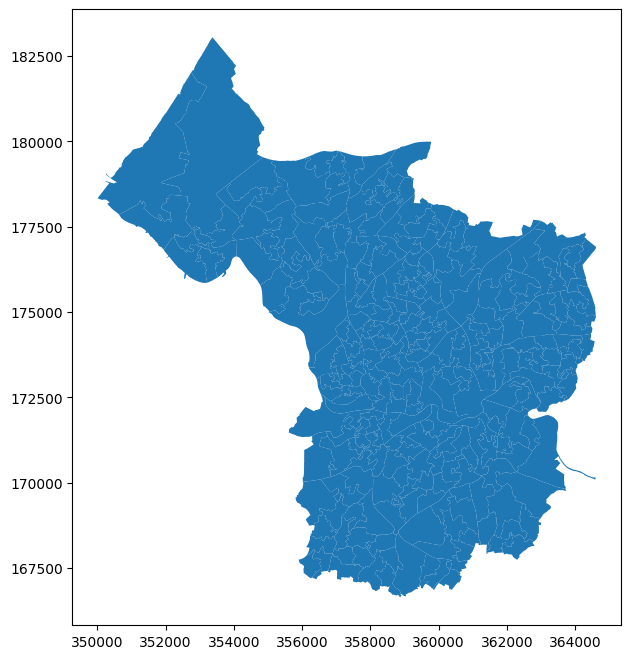

In [ ]:
# Plot the Bristol LSOA data to see what it looks like
# Define the number of plots and figure size
f, ax = plt.subplots(1, figsize=(10, 8))

# Plotting the Bristol LSOA data, specifying the subplot axis
LSOA_bristol.plot(ax=ax)

# Show the plot
plt.show()

The shapefile contains 268 rows and 8 columns, there is 1 x 'int32' column, 4 x 'object' variables that include location infomation such as LSOA21CD (common join column). There are 2 x 'float64' columns 'ShapeSTAre'	'ShapeSTLen'	containing shape area and length these variables contain decimal points eg. 3555.24. There is 1 x 'geometry' variable, this is crucial for visualisation.

The CRS is checked to ensure that the shapefile is projected using the Bristish National Grid (EPSG:27700), this is important when creating an accurate map as 27700 is projected using meters which provides a truthful accurate visualisation oppose to other projections that use degrees.

An initial plot is created to visualise the data and check that the plot runs smoothly.

***Final cleaned Bristol Health dataset***

In [ ]:
# Remove columns not need for anlysis
health = health[['LSOA21CD', 'Very_good_health', 'Very_bad_health', 'healthy', 'unhealthy', 'healthy_perc']]

In [ ]:
# Veiw final cleaned dataset
health

,LSOA21CD,Very_good_health,Very_bad_health,healthy,unhealthy,healthy_perc
0,E01014580,628,49,0,1,69.294342
1,E01014706,492,37,0,1,69.721408
2,E01014691,754,55,0,1,71.485543
3,E01014595,554,37,0,1,71.551724
4,E01014597,553,32,0,1,71.695402
...,...,...,...,...,...,...
262,E01014669,973,8,1,0,92.225705
263,E01014538,1124,8,1,0,92.354571
264,E01014667,1141,5,1,0,92.627267
265,E01014511,923,3,1,0,92.672715


A final health data sub is created containing the common join column 'LSOA21CD', 'Very_good_health', 'Very_bad_health', 'healthy', 'unhealthy' and 'healthy_perc'. Removing extra columns ensures a smooth join between datasets and improve clarity.

***Joining the Health data and Greenspace data together***

In [ ]:
# Merge the cleaned health data and greensub data on the common column (LSOA21CD), merge the greensub data on the left of the health data
green_health = health.merge(greensub, on='LSOA21CD', how='left')

In [ ]:
# Veiw the new dataset
# 267 rows and 10 columns
green_health

,LSOA21CD,Very_good_health,Very_bad_health,healthy,unhealthy,healthy_perc,LAD_name,IMD_rank_country_specific,Average_distance_nearest_Park_Public_Garden_m,Number_postcodes_within_built_up_area
0,E01014580,628,49,0,1,69.294342,Bristol,379.0,362.244028,47.0
1,E01014706,492,37,0,1,69.721408,Bristol,2676.0,174.137410,36.0
2,E01014691,754,55,0,1,71.485543,Bristol,5368.0,219.697718,46.0
3,E01014595,554,37,0,1,71.551724,Bristol,2108.0,182.126550,37.0
4,E01014597,553,32,0,1,71.695402,Bristol,483.0,354.541162,34.0
...,...,...,...,...,...,...,...,...,...,...
262,E01014669,973,8,1,0,92.225705,Bristol,26645.0,275.830655,36.0
263,E01014538,1124,8,1,0,92.354571,Bristol,22489.0,643.712748,41.0
264,E01014667,1141,5,1,0,92.627267,Bristol,30062.0,219.400984,41.0
265,E01014511,923,3,1,0,92.672715,Bristol,24538.0,501.754111,21.0


In [ ]:
# Check for NA values
# There is a difference in the number of rows between datasets, there are 9 missing values (LSOAs) in the greenspace data
green_health.isna().sum()

,0
LSOA21CD,0
Very_good_health,0
Very_bad_health,0
healthy,0
unhealthy,0
healthy_perc,0
LAD_name,9
IMD_rank_country_specific,9
Average_distance_nearest_Park_Public_Garden_m,9
Number_postcodes_within_built_up_area,9


In [ ]:
# Remove rows containing missing data
# This introduces a level bias if the missing data is not random
green_health = green_health.dropna()

Joining the data improves clarity when creating each supervised learning model, also removing the possibility of error as all neccesary data variables are located within one dataset.

The clean greenspace database and health databases contain a missmatched number of rows (greenspace =263, health = 267), this suggests that the greenspace data set is missing values for some LSOAs. Consequently, after the merge, there are 9 rows containing missing values in 4 columns, these rows can be removed using the dropna function. By doing this, uncertainty is decreased however, a level of bias is introduced as some useful data from the other columns has now been removed.

***Final Joined Health and Greenspace dataset***

In [ ]:
# Veiw the final joined dataset that can used for analysis

# Check if the rows have been dropped
# There are now 258 rows and 10 columns
green_health

,LSOA21CD,Very_good_health,Very_bad_health,healthy,unhealthy,healthy_perc,LAD_name,IMD_rank_country_specific,Average_distance_nearest_Park_Public_Garden_m,Number_postcodes_within_built_up_area
0,E01014580,628,49,0,1,69.294342,Bristol,379.0,362.244028,47.0
1,E01014706,492,37,0,1,69.721408,Bristol,2676.0,174.137410,36.0
2,E01014691,754,55,0,1,71.485543,Bristol,5368.0,219.697718,46.0
3,E01014595,554,37,0,1,71.551724,Bristol,2108.0,182.126550,37.0
4,E01014597,553,32,0,1,71.695402,Bristol,483.0,354.541162,34.0
...,...,...,...,...,...,...,...,...,...,...
262,E01014669,973,8,1,0,92.225705,Bristol,26645.0,275.830655,36.0
263,E01014538,1124,8,1,0,92.354571,Bristol,22489.0,643.712748,41.0
264,E01014667,1141,5,1,0,92.627267,Bristol,30062.0,219.400984,41.0
265,E01014511,923,3,1,0,92.672715,Bristol,24538.0,501.754111,21.0


Displaying the final data set helps to ensure data has been joined correctly and there are no missing values. The final datset now contains 258 rows and 10 columns.

***Spatial Join for Chloropleth visualisation***

***Bristol Health Join***

In [ ]:
# Merge the spatial data and bristol_health data on the common column, join the data on the left
bristol_health_lsoa = LSOA_bristol.merge(bristol_health, on='LSOA21CD', how='left')

In [ ]:
# Veiw the newly joined health spatial data set
bristol_health_lsoa

,OBJECTID,LSOA21CD,LSOA21NM,LSOA21LN,Note,ShapeSTAre,ShapeSTLen,geometry,LAD_name,2021_super_output_area_lower_layer,Very_good_health,Good_health,Fair_health,Bad_health,Very_bad_health,All_usual,healthy_perc,health_flag
0,1,E01014674,Bristol 027B,Burchells Green,None,2.282098e+05,3550.007419,"POLYGON ((364137.008 174292.811, 364137.692 17...",Bristol,Bristol 027B,830,570,215.0,72.0,20.0,1707,82.015231,healthy
1,2,E01014485,Bristol 058A,Mina Road,None,2.745500e+05,3443.814587,"POLYGON ((360489.457 174762.742, 360500.687 17...",Bristol,Bristol 058A,1016,670,188.0,68.0,24.0,1966,85.757884,healthy
2,3,E01014486,Bristol 058C,St Agnes,None,2.760687e+05,4333.469290,"POLYGON ((360249.713 174716.608, 360231.659 17...",Bristol,Bristol 058C,1342,910,296.0,113.0,28.0,2689,83.748605,healthy
3,4,E01014487,Bristol 020A,Cromwell Road,None,1.936192e+05,2890.464792,"POLYGON ((359578.466 174989.369, 359584 174985...",Bristol,Bristol 020A,1201,577,168.0,35.0,8.0,1989,89.391654,healthy
4,5,E01014488,Bristol 058B,Upper Montpelier,None,1.880479e+05,2754.125360,"POLYGON ((359722 174779, 359728 174740, 359729...",Bristol,Bristol 058B,1095,650,222.0,57.0,8.0,2032,85.875984,healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,264,E01033908,Bristol 061B,Queens Square,None,1.390191e+05,2051.371016,"POLYGON ((358616.542 172917.385, 358636.938 17...",Bristol,Bristol 061B,801,548,106.0,27.0,5.0,1487,90.71957,healthy
264,265,E01033909,Bristol 061C,The Centre,None,3.307642e+05,4069.629210,"POLYGON ((358500 173055, 358505 173048, 358511...",Bristol,Bristol 061C,1227,754,149.0,15.0,4.0,2149,92.18241,healthy
265,266,E01033910,Bristol 061E,Bathurst Basin,None,2.211230e+05,2383.043414,"POLYGON ((358686 172500, 358688 172497, 358691...",Bristol,Bristol 061E,767,455,113.0,28.0,14.0,1377,88.743646,healthy
266,267,E01014496,Bristol 008E,Avonmouth Docks,None,4.878726e+06,17407.108275,"POLYGON ((352751.267 182029.167, 352887.891 18...",NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,<NA>,<NA>,NaN


Merging the spatial Bristol LSOA data to bristol_health instead of the final green_health dataset allows all previous data to be used in the visualisation (as some useful data was lost during the merge).  

This data set contains 268 rows and 18 columns including a geometry column containing polygon data that can be used to plot the health data visually so that spatial comparisions between variables can be identified.

***Greenspace Join***

In [ ]:
# Merge the spatial data and the greensub dataset on the common column, join the data on the left
green_lsoa = LSOA_bristol.merge(greensub, on='LSOA21CD', how='left')

In [ ]:
# Veiw the newly joined greenspace spatial data set
green_lsoa

,OBJECTID,LSOA21CD,LSOA21NM,LSOA21LN,Note,ShapeSTAre,ShapeSTLen,geometry,LAD_name,IMD_rank_country_specific,Average_distance_nearest_Park_Public_Garden_m,Number_postcodes_within_built_up_area
0,1,E01014674,Bristol 027B,Burchells Green,None,2.282098e+05,3550.007419,"POLYGON ((364137.008 174292.811, 364137.692 17...",Bristol,8933.0,855.274731,29.0
1,2,E01014485,Bristol 058A,Mina Road,None,2.745500e+05,3443.814587,"POLYGON ((360489.457 174762.742, 360500.687 17...",Bristol,12992.0,152.279693,55.0
2,3,E01014486,Bristol 058C,St Agnes,None,2.760687e+05,4333.469290,"POLYGON ((360249.713 174716.608, 360231.659 17...",Bristol,3573.0,96.271032,71.0
3,4,E01014487,Bristol 020A,Cromwell Road,None,1.936192e+05,2890.464792,"POLYGON ((359578.466 174989.369, 359584 174985...",Bristol,17138.0,255.706772,30.0
4,5,E01014488,Bristol 058B,Upper Montpelier,None,1.880479e+05,2754.125360,"POLYGON ((359722 174779, 359728 174740, 359729...",Bristol,11617.0,294.922881,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...
263,264,E01033908,Bristol 061B,Queens Square,None,1.390191e+05,2051.371016,"POLYGON ((358616.542 172917.385, 358636.938 17...",NaN,NaN,NaN,NaN
264,265,E01033909,Bristol 061C,The Centre,None,3.307642e+05,4069.629210,"POLYGON ((358500 173055, 358505 173048, 358511...",NaN,NaN,NaN,NaN
265,266,E01033910,Bristol 061E,Bathurst Basin,None,2.211230e+05,2383.043414,"POLYGON ((358686 172500, 358688 172497, 358691...",NaN,NaN,NaN,NaN
266,267,E01014496,Bristol 008E,Avonmouth Docks,None,4.878726e+06,17407.108275,"POLYGON ((352751.267 182029.167, 352887.891 18...",Bristol,11235.0,731.382002,79.0


Greenspace data is merged with spatial data so that it can be plotted. This dataset does contain NaN values however, these will not be removed as they will also plotted and highlighted on the map to show specific areas that have limited infomation, this can later be evaluated in the results section.

# **Section 6: Data Analysis - Choropleths, Correlation and Classification**

This section uses multiple data analysis techniques aiming to answer the selected research questions.

By investigating the relationships between data variables using choropleth maps and correlations, the impact of the chosen variables can be assessed visually and quantified helping to prove their connection to the spatial variability in health classifications across Bristol proving that they are valid variables that can be used in the creation supervised leaning models.The chosen variables will be used in the creation of two supervised learning classification models a Decision Tree and K-nearest Neighbours model.


***Choropleths***

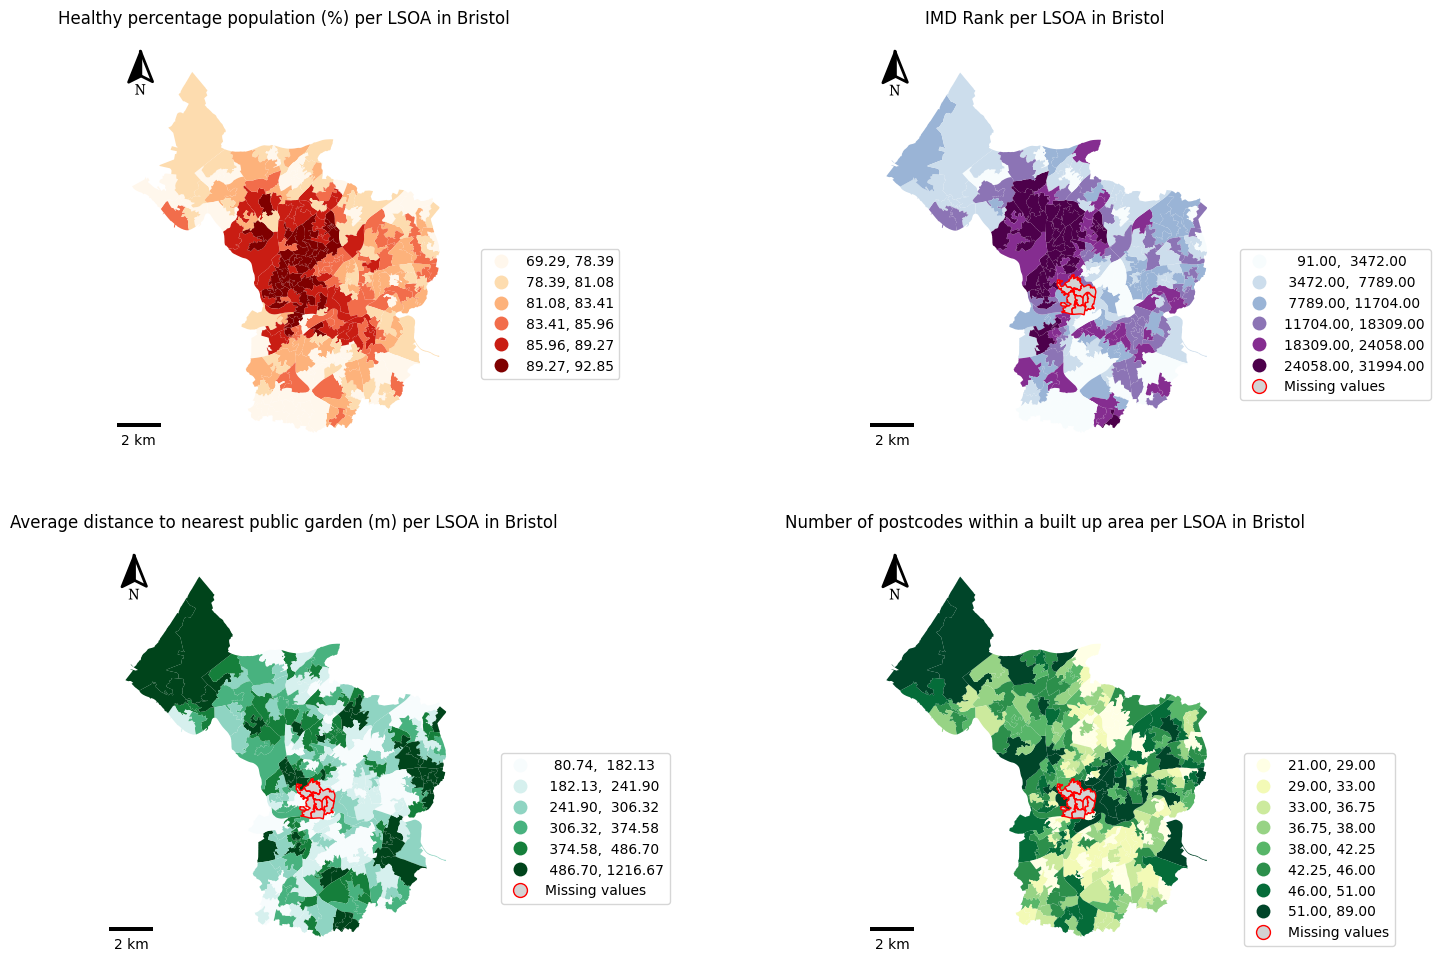

In [ ]:
#plot your choropleths
fig, ax = plt.subplots(2, 2, figsize=(18, 12))

#Plot 1
#plot health data setting the scheme to quantiles, colour to OrRd and the k=6
bristol_health_lsoa.plot(ax = ax[0, 0], column = 'healthy_perc', scheme = 'quantiles',cmap = 'OrRd', k=6, legend = True)
#plot the title on the axis [0,0]
ax[0,0].set_title('Healthy percentage population (%) per LSOA in Bristol')

# Plot 2
# Plot the IMD rank data setting the scheme to quantiles and map colour to BuPu, k=6 to give 6 bins/catagories
# Using missing_kwds create a labels specifically for missing values within the data
# Set the colour to light grey and edgecolor to red and give the label Missing Values that will appear in the legend.
green_lsoa.plot(ax = ax[0, 1], column = 'IMD_rank_country_specific', scheme = 'quantiles',cmap = 'BuPu', k=6, legend = True, missing_kwds={'color': 'lightgrey',"edgecolor": "red",
        "label": "Missing values"})
#plot the title on axis [0,1] - the map will appear in the top right of the plot
ax[0,1].set_title('IMD Rank per LSOA in Bristol')

# Plot 3
# Plot the Average distance to nearest park/public garden data setting the scheme to quantiles and map colour to BuGn, k=6 to give 6 bins/catagories
# Using missing_kwds create a labels specifically for missing values within the data
green_lsoa.plot(ax = ax[1, 0], column = 'Average_distance_nearest_Park_Public_Garden_m', scheme = 'quantiles',cmap = 'BuGn', k=6, legend = True, missing_kwds={'color': 'lightgrey',
 "edgecolor": "red", "label": "Missing values"})
#plot the title on the axis [1,0]
ax[1,0].set_title('Average distance to nearest public garden (m) per LSOA in Bristol')

# Plot 4
# Plot the postcodes data variable setting the scheme to quantiles and map colour to YlGn
# k=6 to give 8 bins/catagories, increase the bins to 8 so there are more catagories so patterns can be identified easily
# Using missing_kwds create a labels specifically for missing values within the data
green_lsoa.plot(ax = ax[1, 1], column = 'Number_postcodes_within_built_up_area', scheme = 'quantiles',cmap = 'YlGn', k=8, legend = True, missing_kwds={'color': 'lightgrey',
 "edgecolor": "red", "label": "Missing values"})
#plot the title on the axis [1,1]
ax[1,1].set_title('Number of postcodes within a built up area per LSOA in Bristol')


# Turn off the axis for plot 1 as to not distract from the presented data
ax[0,0].set_axis_off()
# Turn off the axis for plot 2 as to not distract from the presented data
ax[0,1].set_axis_off()
# Turn off the axis for plot 3 as to not distract from the presented data
ax[1,0].set_axis_off()
# Turn off the axis for plot 4 as to not distract from the presented data
ax[1,1].set_axis_off()


# Move legend per plot
# plot 1
leg = ax[0,0].get_legend()
leg.set_bbox_to_anchor((1.50, 0.5))
# plot 2
leg = ax[0,1].get_legend()
leg.set_bbox_to_anchor((1.60, 0.5))
# plot 3
leg = ax[1,0].get_legend()
leg.set_bbox_to_anchor((1.60, 0.5))
# plot 4
leg = ax[1,1].get_legend()
leg.set_bbox_to_anchor((1.50, 0.5))

# Plot 1
# Add a north arrow, plot on axis positioning it in a suitable place on the map set the scale, set for each plot
add_north_arrow(ax=ax[0,0], xlim_pos=0.07, ylim_pos=.93, text_scaler=2.5, text_yT=-1.25, scale=.75)
# Plot 2
add_north_arrow(ax=ax[0,1], xlim_pos=0.07, ylim_pos=.93, text_scaler=2.5, text_yT=-1.25, scale=.75)
# Plot 3
add_north_arrow(ax=ax[1,0], xlim_pos=0.07, ylim_pos=.93, text_scaler=2.5, text_yT=-1.25, scale=.75)
# Plot 4
add_north_arrow(ax=ax[1,1], xlim_pos=0.07, ylim_pos=.93, text_scaler=2.5, text_yT=-1.25, scale=.75)

# Plot 1
# Add a scalebar setting the pixel equal to 1m, set on each individual axis, set the location to lower left for consistency
scalebar = ScaleBar(1, location='lower left')
ax[0,0].add_artist(scalebar)
# Plot 2
scalebar = ScaleBar(1, location='lower left')
ax[0,1].add_artist(scalebar)
# Plot 3
scalebar = ScaleBar(1, location='lower left')
ax[1,0].add_artist(scalebar)
# PLot 4
scalebar = ScaleBar(1, location='lower left')
ax[1,1].add_artist(scalebar)

plt.show()

The above figure shows a choropleth plot of 4 maps showing the spatial variation in the healthy population, IMD Rank, average distance to the nearest public park/gardens and number of postcodes within a built up area across Bristol LSOA. This plot allows for a spatial analysis of each variable allowing for comparisons to be made between them all.

Missing values have been diplayed on the choropleth maps to identify areas that are not represented within the data, this was done to improve clarity and represent the data truthfully without introducing bias.

North arrows and scale bars where added onto the maps to provided geographical context, axis labels were removed so that the figure was clear.

***Correlations***

In [ ]:
# Create a subset that can be used in the correlation matix consisting of only numerical values
green_health_corr = green_health[['Very_good_health','Very_bad_health','IMD_rank_country_specific','Average_distance_nearest_Park_Public_Garden_m','Number_postcodes_within_built_up_area']]

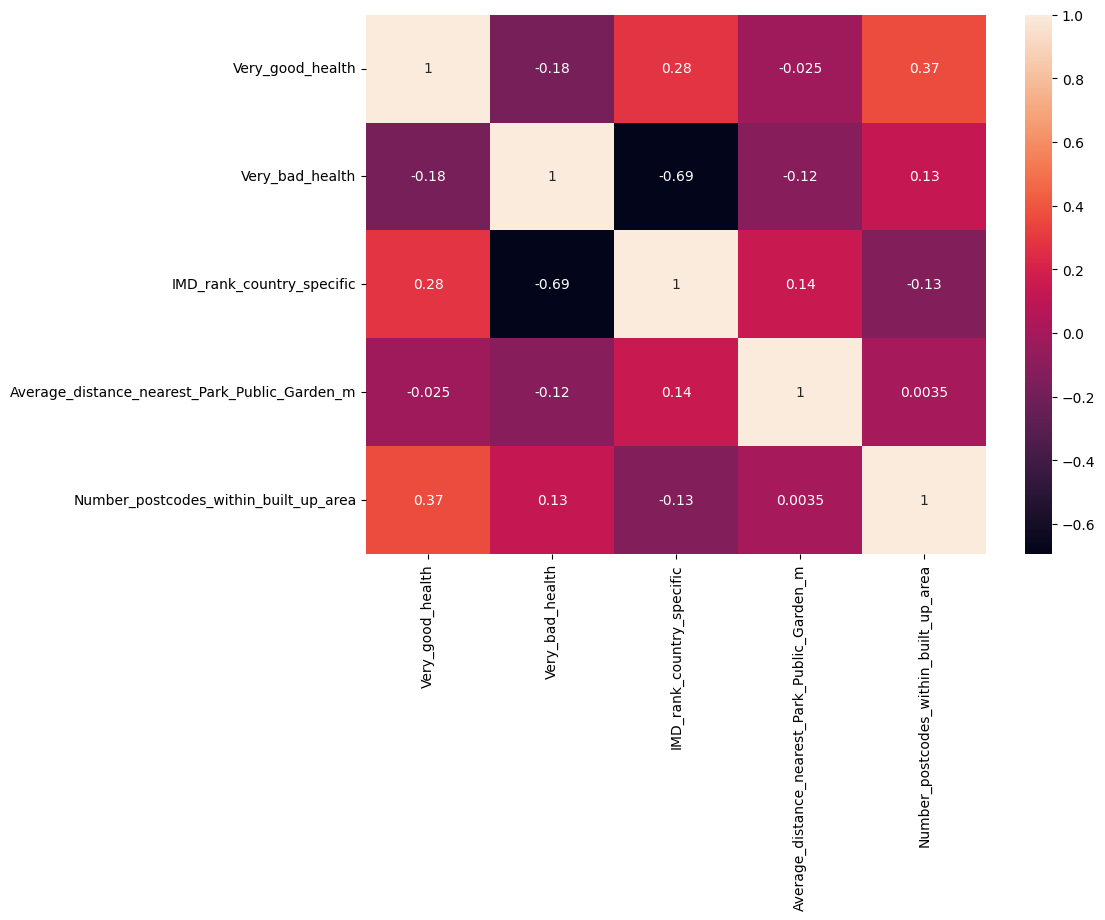

In [ ]:
correlation_matrix = green_health_corr.corr()

# Create the heatmap
plt.figure(figsize = (10,7))
sns.heatmap(correlation_matrix, annot=True)
plt.show()

A subset including only chosen numeric columns is created, from this, a correlation matrix is made and plotted as a heatmap using the seaborn libary. The matrix diplays the correlation coefficient values between each variable showing how one impacts the other.

A correlation index also checks for multicolinearity between variables, this is important to check for because if a coefficient value is <0.9 this suggests multicolinearity is present which can decrease the acurracy of a model and skew results. There is no multicolinearity present in the above correlation matrix.

***Classification***

***Create labels***

In [ ]:
# convert to an array using .to_numpy()
labels_array =  green_health['healthy'].to_numpy()

In [ ]:
# Veiw the array
labels_array

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
# the label encoder is used to transform a selected column from the dataset into integers that can be used in the supervised learning model
label_encoder_classType = LabelEncoder()
# select the healthy variable to be used as labels
green_health['healthy'] = label_encoder_classType.fit_transform(green_health['healthy'])

/tmp/ipython-input-232446150.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  green_health['healthy'] = label_encoder_classType.fit_transform(green_health['healthy'])


Supervised learning models use labels (labeled dataset) to identify patterns between variables used to create test, trian, split datasets and classify them based on these patterns. The labels are created from the binary health class data created during data wrangling from the healthy percentage. The label array can be veiwed and shows the different binary values (0 or 1). The array shows that there is an imbalance between 0 (the minority or'unhealthy' flag) and 1 (the majority or 'healthy' flag).

Only one health variable needs to be selected from the binary health data as they contain the same values, using the label encoder the 'healthy' variable is transormed into the labels.

***Create train and test data sets***

In [ ]:
# Create a sub set that only includes the variables that will be used to train the model
green_health_sub = green_health[['Average_distance_nearest_Park_Public_Garden_m','IMD_rank_country_specific','Number_postcodes_within_built_up_area']]

In [ ]:
# Convert the green_health_sub data to an array
green_health_sub_array =  green_health_sub.to_numpy()

In [ ]:
# Divide into train, test and label in a 75:25 split
# Set the random state value to 42
train_data, test_data, train_lab, test_lab = train_test_split(green_health_sub_array, labels_array, random_state=42)

In [ ]:
# Veiw the shape of the data to find the instances
# 193 instances
train_data.shape

(193, 3)

In [ ]:
# Veiw the shape of the data to find the instances
# 65 instances
test_data.shape

(65, 3)

The green health sub data is converted into a numpy array so it can then be used to create test and train values to train the models. Using a 75:25 split and random state of 42, the green_health_sub_array and labels_array are divided into train and test data. There are 193 instances in the train data and 65 instances in the test data.

***Descision Tree - Model Building***

In [ ]:
# Create the decision tree
# fit the model to the train and test datasets
tree = DecisionTreeClassifier(random_state=42)
tree.fit(train_data, train_lab)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Create the predictions using the model and test data
predictions = tree.predict(test_data)

In [ ]:
# Veiw the predictions array
predictions

array([0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0])

In [ ]:
# Create a new dataset containing the predictions
class_pred = pd.DataFrame(list(predictions))

In [ ]:
# Join the predicted values and the actual labels from the test dataset
class_pred['healthy'] = pd.DataFrame(list(test_lab))

In [ ]:
# Changes the name of the column within class_pred called '0' to 'Prediction'
class_pred.rename(columns={0:'Prediction'}, inplace=True)

In [ ]:
# Check that the column has been remnamed and that the join has worked correctly
class_pred

,Prediction,healthy
0,0,0
1,1,0
2,0,0
3,1,1
4,1,1
...,...,...
60,1,1
61,1,1
62,0,1
63,1,1


In [ ]:
# Create a new column called match
class_pred['match']=None

In [ ]:
# In the match column display if the prediction and labels match printing true or false
class_pred['match'] = np.where(class_pred['Prediction'] == class_pred['healthy'], True, False)

In [ ]:
# Call the class prediction dataset to visualise it
class_pred

,Prediction,healthy,match
0,0,0,True
1,1,0,False
2,0,0,True
3,1,1,True
4,1,1,True
...,...,...,...
60,1,1,True
61,1,1,True
62,0,1,False
63,1,1,True


Firstly, the descision tree model is fitted to the test and train data sets, set the random state to 42 to ensure consistency. Using the model, preditions are created using the test data, these can be veiwed as an array. A new dataset is then formed containing the predictions and then joined to the actual test labels. The predictions column within the class_pred subset is renamed as 'Predictions' for clarity.

A new column is then created called 'match', displaying True or False if the two variable values match per row.

***Descision Tree - Confusion Matrix***

In [ ]:
# Create a confusion matrix
confusion_matrix = metrics.confusion_matrix(test_lab, predictions)

In [ ]:
# Print the classification report
print(metrics.classification_report(test_lab, predictions, zero_division = 0))

              precision    recall  f1-score   support

           0       0.59      0.53      0.56        19
           1       0.81      0.85      0.83        46

    accuracy                           0.75        65
   macro avg       0.70      0.69      0.69        65
weighted avg       0.75      0.75      0.75        65



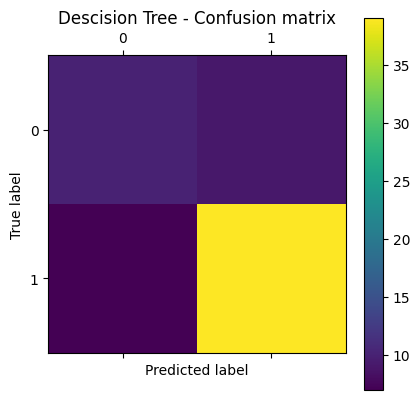

In [ ]:
# plot the confusion matrix for the decision tree classifier
plt.matshow(confusion_matrix)
plt.title('Descision Tree - Confusion matrix')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

A classification report displays the precision and recall for each label as well as the overall accuracy score of the model.

With 0.75 accuracy, the model can predict health outcomes based on Greenspace data variables: 'Average_distance_nearest_Park_Public_Garden_m', 'IMD_rank_country_specific', 'Number_postcodes_within_built_up_area' using a descision tree model.

A confusion matrix can then be printed, this shows a visual representation of the accuracy of the model showing where the labels did and did not match.

***Knearest neighbours (Knn) - Model Building***

In [ ]:
# Create the classifier assigning the value 20 to the neighbors
knn = KNeighborsClassifier(n_neighbors=20)

The K nearest neighbours classifier model is created and the number of neighbours is set to 20, this allows the model to compare the 20 nearest neighbours to a single data point. The Knn model is very sensitive to changes in this number, the larger the number of neighbours, the more generalised the classification.

In [ ]:
# Fit the model to the data
knn.fit(train_data, train_lab)

KNeighborsClassifier(n_neighbors=20)

In [ ]:
# Create the predictions
predictions = knn.predict(test_data)

In [ ]:
# Veiw the predictions
predictions

array([0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0])

In [ ]:
# Create a new dataset containing the predictions
classknn_pred = pd.DataFrame(list(predictions))

In [ ]:
# Join the predicted values and the actual labels from the test dataset
classknn_pred['healthy'] = pd.DataFrame(list(test_lab))

In [ ]:
# Changes the name of the column within classknn_pred called '0' to 'Prediction'
classknn_pred.rename(columns={0:'Prediction'}, inplace=True)

In [ ]:
# Check that the column has been remnamed and that the join has worked correctly
classknn_pred

,Prediction,healthy
0,0,0
1,1,0
2,0,0
3,1,1
4,1,1
...,...,...
60,1,1
61,1,1
62,0,1
63,1,1


In [ ]:
# Create a new column called match
classknn_pred['match']=None

In [ ]:
# In the match column display if the prediction and labels match printing true or false
classknn_pred['match'] = np.where(classknn_pred['Prediction'] == classknn_pred['healthy'], True, False)

In [ ]:
classknn_pred

,Prediction,healthy,match
0,0,0,True
1,1,0,False
2,0,0,True
3,1,1,True
4,1,1,True
...,...,...,...
60,1,1,True
61,1,1,True
62,0,1,False
63,1,1,True


The process of building the Knn model is very similar to that of the descision tree however the Knn model requires set parameters (n_neighbours) to be set before the model can be fitted. The descision tree does not require any parameters and classifies the healthy/unhealthy lables based on entrophy in a heiarachical classification sytem.

***Knn - Confusion Matrix***

In [ ]:
# Create a confusion matrix
confusion_matrix = metrics.confusion_matrix(test_lab, predictions)

In [ ]:
# Print the classification report for the model
print(metrics.classification_report(test_lab, predictions, zero_division = 0))

              precision    recall  f1-score   support

           0       0.69      0.58      0.63        19
           1       0.84      0.89      0.86        46

    accuracy                           0.80        65
   macro avg       0.76      0.74      0.75        65
weighted avg       0.79      0.80      0.79        65



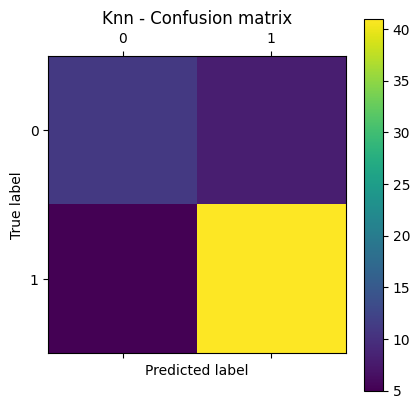

In [ ]:
# Plot the confusion matrix
plt.matshow(confusion_matrix)
plt.title('Knn - Confusion matrix')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

 Printing a classification report displays the model acuracy (0.8).A confusion matrix is then fitted with the model predictions and test labels to produce visualisation of the model performance.

# **Section 7: Results**
***Choropleth Maps***

The choropleth provides a good initial visualisation of the correlations between different spatial distributions of the chosen variables across Bristol, high health across Bristol has a strong correlation to high IMD rankings as well as this low health appears in areas with low IMD rankings, this is expected as health indicators are used in the creation of the IMD rank. However, this correlation shows that other socioeconomic conditions included in the IMD ranking such as employment, education level and crime differ greatly between Bristol LSOAs and suggest that where there is poor health there is also an increase in crime, increase in unemployment and lower education levels. Some LSOAs with higher health rankings still have low IMD rankings, this suggests that other conditions considered in the ranking are have a larger influence in these areas.

The south of the city exhibits overall lower health and lower IMD, a similar pattern is mirrored in the far north of the city. This suggest that these LSOAs are more rural communities with less access to healthcare, house prices in these areas may be cheaper and therefore more affordable for households with high unemployment/lower education levels. LSOAs in the north of the city also display the furthest distances from public greenspace in contrast, in the centre of the city there is good overall health and low distance to the nearest park, despite this the IMD rank in this area is very low (missing data makes correlations harder to interpret in this area). There is a high proportion of postcodes in the city centre suggesting a higher population density, this may increase crime levels therefore leading to low IMD ranking.

Choropleth maps show that there are definite correlation between the chosen variables however, to further investigate these correlations, a statistical comparison provides clarity and decreases human error when visually interpreting results.

***Correlation Coefficient heatmap***

The heatmap displays the correlation coefficients between each of the variables, the map displays a very strong negative correlation between IMD rank and very bad health (-0.69) this suggests that worse health and higher deprivation are high correlated. IMD rank and very good health have a moderate correlation suggesting that even though there is a slightly weaker correlation between these two variables they do still influence each other. There is also a strong correlation between number of postcodes within a built up area and very good health (0.37) this suggests that areas that have a higher population density potentially in the city centre have better access to health care facilities within closer proximity and better transport links. The link between very bad health and number of postcodes is weaker (0.13), this suggests that other factors are more influential when determining very bad health.

Overall, despite previous studies proving that there is a correlation between greenspace and health, average distance to the nearest public park/garden has the weakest correlation with health variables, there is however a weak positive correlation between greenspace and IMD rank suggesting that areas with better access to greenspace have higher rankings.

These results show that there are statistically significant correlations between data variables and therefore should be able to train a supervised learning model to predict healthy and unhealthy LSOAs, despite this, some variables maybe more reliable for model training than others.

***Model Results - Decision Tree***

The results from the decision tree model show that after being trained with the 'train_data' the model was able to predict health class labels with a mean accuracy of 0.75. The classification report shows that the precision differed when predicting 0 (unhealthy) and 1 (healthy) class. The model was less precise when predicting the minority unhealthy class with 0.59 accuracy compared to the majority healthy class with 0.81 accuracy. These results can clearly be visualised in the decision tree confusion matrix, showing that the healthy class had more true matches. Despite this, the model did still predict 0 class with some accuracy however this is hard to see on the matrix due to the imbalance of healthy/unhealthy labels in the training data.

***Model Results - Knearest neighbours***

The Knn model had a accuracy score of 0.8 which is 0.05 higher than the decision tree classifier, the precision for both classes was also higher for the knn model with a significant improvement of +0.1 (0.69) in the classification of unhealthy LSOAs. There was also a slight precision increase in the prediction of the healthy class (0.84). The knn correlation matrix however follows a very similar pattern to that of decision tree with the imbalance in class labels impacting the model accuracy.


# **Section 8: Discussion**

The discussion aims to evaluate and explain the main results from this project aiming to answer the main research questions.

***Research Question 1:***

Results show that the chosen variables number of postcodes within a built up area and IMD rank have strong correlations between health variables especially 'healthy' class. Visual comparison suggested that there was a link between very good health and number of postcodes, statistical analysis proved that these variables had a strong positive correlation suggesting that built up areas in Bristol such as the city centre have better access to healthcare in contrast to rural communities. This suggests that distance to facilities may be an important factor when determining health class, previous studies also suggest that differing socioeconomic conditions (often worse in rural communities) within cities make it harder for residents to access the help they need (Sapkota et al. 2024).

Overall, number of postcodes within a built up area is a valid and reliable variable that can help predict 'healthy' LSOAs, despite this a weaker correlation with very bad health suggests that more data is needed to predict ‘unhealthy’ LSOAs from postcode data. Future studies could combine Bristol postcode data with that of a larger city such as Birmingham to improve sample size and increase accuracy.

IMD ranking exhibits strong correlations between both health factors especially very bad health, this shows that other factors associated with deprivation also lead to very bad health. Previous studies show that employment rates have a higher weighting than health in the creation of the IMD rank (Watson et al.2019), this suggests that levels of unemployment in an LSOA can lead to lower incomes therefore making it harder for people access NHS and private healthcare, explaining one reason for this correlation.

A surprising result from the statistical analysis showed that there was little to no correlation between average access to public parks/gardens and health factors. This suggests that average access to greenspace is not a good indicator of health class for this health dataset as there is no strong correlation despite there being some visual links. One reason for this might be that Bristol is a relatively small city creating a small sample size, furthermore, Bristol is considered one of the greenest cities in the UK. As a result, all LSOAs are within a short distance of public greenspace therefore making differences hard to quantify and making links hard to identify between health classes.

Despite this, previous studies do suggest there is a link between increased access to greenspace and the overall increase of general health. Greenspace acts a stress reliever with public parks providing a space to exercise improving physical health and mental health due to the social benefits (Maas et al. 2006, Richardson et al.2013). In future studies, a different dataset could be used to represent greenspace such as percentage of households with private gardens per LSOA, this will further aid the prediction of health class variables and increase model accuracy scores.

***Research Question 2 & 3:***

Results show that the supervised learning models can predict health classes (0=unhealthy and 1=healthy) to a varying degree of accuracy, both models could not predict health outcomes <0.9, this may be due to decision tree overfitting the data or the knn model being sensitive to outliers within the data. Overall, the Knn model was most accurate (0.8) and is therefore better suited to predicting health class from this dataset, when compared to the decision tree model, the Knn displayed a better accuracy when predicting the minority class, this may be because the use of parameters or that Knn models work well on small datasets (Suyal and Goyal,2022). Despite this, there is still a degree of uncertainty with the Knn model as the train data contained an unbalanced number of healthy and unhealthy labels.

Previous studies suggest that one solution for this includes the creation of a larger train (health) dataset (Ajiboye et al. 2015) that contains an increased number of 'unhealthy' LSOA values. Minority and majority classes may still be imbalanced in the larger train dataset however, by increasing the amount of infomation imputted in the model, classification patterns will become easier to recognise therefore improving the precision, recall and overall accuracy of the supervised learning model making it fit for purpose. Consequently, with improvements in the train dataset, this model will be able to accurately predict health class based on OS Greenspace data. The model will be useful for local governments when planning building developments and help to assess health risk of local communities when designing new housing.





# **Section 9: Conclusion**

In conclusion, this mini project has identified that some variables within the OS greenspace dataset are useful for training supervised learning models such as IMD rank. Some variables are better at helping to identify 'healthy' class labels and variables aiding the prediction of 'unhealthy' labels are limited. To improve the quality of the model, there should be an increase in variables aimed at identifying the minority classes such as demographic data. As well as this, a Greenspace variable better suited to the health data should be used to help increase the association between access to greenspace and health factors helping to improve model accuracy.

Furthermore, the K nearest neighbours model was found to be best suited for predicting health outcomes however, there were still uncertainties surrounding the overall accuracy of the model and future studies should focus on improving the balance between health class labels and increase the size of the train data sets to improve model reliability, this could include the addition of health data from other UK cities.

Overall, with certain improvements the supervised learning models will be able to help local governments to identify vulnerable communities based on the chosen OS demographic and environmental variables, this will allow better planning decisions to be made during urban planning ensuring that LSOA communities remain healthy or improve their overall health. This could be done with the addition of more public greenspace areas or an increase in healthcare facilities in rural unhealthy LSOAs.

# **Section 10: References**
Ajiboye, A.R., Abdullah-Arshah, R. and Hongwu, Q., 2015. Evaluating the effect of dataset size on predictive model using supervised learning technique.

Fenning, K. and Ting, H., 2025. Tools and evidence for green space investment in new town planning. Cities & Health, pp.1-7.

Maas, J., Verheij, R.A., Groenewegen, P.P., De Vries, S. and Spreeuwenberg, P., 2006. Green space, urbanity, and health: how strong is the relation?. Journal of epidemiology & community health, 60(7), pp.587-592.

Matheney, A., del Pulgar, C.P. and Shokry, G., 2021. A green capital for all?: Austerity, inequalities and green space in Bristol. In The Green City and Social Injustice (pp. 49-60). Routledge.

Muhammad, L.J., Algehyne, E.A., Usman, S.S., Ahmad, A., Chakraborty, C. and Mohammed, I.A., 2021. Supervised machine learning models for prediction of COVID-19 infection using epidemiology dataset. SN computer science, 2(1), p.11.

NumPy (2026), numpy.where — NumPy documentation.Available: https://numpy.org/doc/stable/reference/generated/numpy.where.html (Accessed: 20/01/2026).

Oates, L.L. and Firth, N., 2020. Deprivation, access and outcomes in health psychology treatment. Mental Health Review Journal, 25(2), pp.139-151.

Office for National Statistics (ONS), released 19 January 2023, ONS website, statistical bulletin, General health, England and Wales: Census 2021

Pandas(2026), pandas.DataFrame.isin — pandas documentation. Available:https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.isin.html (Accessed: 20/01/2026).

Richardson, E.A., Pearce, J., Mitchell, R. and Kingham, S., 2013. Role of physical activity in the relationship between urban green space and health. Public health, 127(4), pp.318-324.

Sapkota, S., Tiwary, M.R., Zare, M.K.B. and Kumar, P., 2024. Access to Healthcare Facilities and Social Well-being in Urban Areas. Journal of Applied Bioanalysis, 10(2), pp.243-251.

Shaw, M., 2004. Housing and public health. Annu. Rev. Public Health, 25(1), pp.397-418.

Suyal, M. and Goyal, P., 2022. A review on analysis of k-nearest neighbor classification machine learning algorithms based on supervised learning. International Journal of Engineering Trends and Technology, 70(7), pp.43-48.

Watson, V., Dibben, C., Cox, M., Atherton, I., Sutton, M. and Ryan, M., 2019. Testing the expert based weights used in the UK’s index of multiple deprivation (IMD) against three preference-based methods. Social Indicators Research, 144(3), pp.1055-1074.

Wolch, J.R., Byrne, J. and Newell, J.P., 2014. Urban green space, public health, and environmental justice: The challenge of making cities ‘just green enough’. Landscape and urban planning, 125, pp.234-244.


